# 1. Import et visulaisation des donnees

In [1]:
%pip install mlflow dagshub

import os
import mlflow
from dagshub import DAGsHubLogger

# 1. Authentification
os.environ["MLFLOW_TRACKING_USERNAME"] = "ibou224"  # ton username DagsHub
os.environ["MLFLOW_TRACKING_PASSWORD"] = "fd9b9c07539f6c3654d5b4932b243aafd02a9e32" 

# 2. Connexion au serveur MLflow DagsHub
mlflow.set_tracking_uri("https://dagshub.com/ibou224/Satisfaction-Client-ProjetIA2025.mlflow")

# 3. Définir l’expérience
mlflow.set_experiment("SatisfactionClient")

# 4. Test : créer un run
with mlflow.start_run():
    mlflow.log_param("example_param", 123)
    mlflow.log_metric("example_metric", 0.95)

print("Run envoyé avec succès !")


[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: mlflow in c:\users\ibrahim traore\appdata\local\programs\python\python312\lib\site-packages (3.6.0)

🏃 View run angry-squirrel-71 at: https://dagshub.com/ibou224/Satisfaction-Client-ProjetIA2025.mlflow/#/experiments/0/runs/db15fb0b47194d5ea9c3ce6ffe126f28
🧪 View experiment at: https://dagshub.com/ibou224/Satisfaction-Client-ProjetIA2025.mlflow/#/experiments/0
Run envoyé avec succès !


In [2]:
# Import des bibliotheques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# 1. Charger les fichiers CSV
orders = pd.read_csv("olist_orders_dataset.csv")
order_items = pd.read_csv("olist_order_items_dataset.csv")
payments = pd.read_csv("olist_order_payments_dataset.csv")
reviews = pd.read_csv("olist_order_reviews_dataset.csv")
customers = pd.read_csv("olist_customers_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")

In [4]:
# 2. Fusionner les tables
df = orders.merge(reviews, on="order_id", how="inner") \
           .merge(order_items, on="order_id", how="left") \
           .merge(payments, on="order_id", how="left") \
           .merge(customers, on="customer_id", how="left") \
           .merge(products, on="product_id", how="left")


In [5]:
# 3. Nettoyer les dates
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])
df["order_delivered_customer_date"] = pd.to_datetime(df["order_delivered_customer_date"])
df["order_estimated_delivery_date"] = pd.to_datetime(df["order_estimated_delivery_date"])


In [6]:
# 4. Features livraison
df["delai_livraison"] = (df["order_delivered_customer_date"] - df["order_purchase_timestamp"]).dt.days
df["retard_livraison"] = (df["order_delivered_customer_date"] - df["order_estimated_delivery_date"]).dt.days

# 5. Features paiement
df["nb_versements"] = df["payment_installments"]
df["valeur_paiement"] = df["payment_value"]

# 6. Features produit
df["prix_total"] = df.groupby("order_id")["price"].transform("sum")
df["nb_articles"] = df.groupby("order_id")["order_item_id"].transform("count")

# 7. Features avis
df["longueur_commentaire"] = df["review_comment_message"].fillna("").apply(lambda x: len(x.split()))

In [7]:
# 8. Variable cible satisfaction
def satisfaction_label(score):
    if score > 3:
        return 1
    else :
        return 0

df["satisfaction"] = df["review_score"].apply(satisfaction_label)

In [8]:
# 9. Garder seulement les colonnes utiles
final_df = df[[
    "order_id", "customer_id", "product_id", "product_category_name",
    "delai_livraison", "retard_livraison", "nb_versements", "valeur_paiement",
    "prix_total", "nb_articles", "longueur_commentaire", "satisfaction"
]]

In [9]:
# 10. Sauvegarder le dataset final
final_df.to_csv("olist_dataset_prepared.csv", index=False)


In [10]:
print("Dataset final sauvegardé : olist_dataset_prepared.csv")
final_df.head()

Dataset final sauvegardé : olist_dataset_prepared.csv


,order_id,customer_id,product_id,product_category_name,delai_livraison,retard_livraison,nb_versements,valeur_paiement,prix_total,nb_articles,longueur_commentaire,satisfaction
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,87285b34884572647811a353c7ac498a,utilidades_domesticas,8.0,-8.0,1.0,18.12,89.97,3,32,1
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,87285b34884572647811a353c7ac498a,utilidades_domesticas,8.0,-8.0,1.0,2.00,89.97,3,32,1
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,87285b34884572647811a353c7ac498a,utilidades_domesticas,8.0,-8.0,1.0,18.59,89.97,3,32,1
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,595fac2a385ac33a80bd5114aec74eb8,perfumaria,13.0,-6.0,1.0,141.46,118.70,1,4,1
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,aa4383b373c6aca5d8797843e5594415,automotivo,9.0,-18.0,3.0,179.12,159.90,1,0,1


In [11]:
df = pd.read_csv('olist_dataset_prepared.csv')
df.head()

,order_id,customer_id,product_id,product_category_name,delai_livraison,retard_livraison,nb_versements,valeur_paiement,prix_total,nb_articles,longueur_commentaire,satisfaction
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,87285b34884572647811a353c7ac498a,utilidades_domesticas,8.0,-8.0,1.0,18.12,89.97,3,32,1
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,87285b34884572647811a353c7ac498a,utilidades_domesticas,8.0,-8.0,1.0,2.00,89.97,3,32,1
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,87285b34884572647811a353c7ac498a,utilidades_domesticas,8.0,-8.0,1.0,18.59,89.97,3,32,1
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,595fac2a385ac33a80bd5114aec74eb8,perfumaria,13.0,-6.0,1.0,141.46,118.70,1,4,1
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,aa4383b373c6aca5d8797843e5594415,automotivo,9.0,-18.0,3.0,179.12,159.90,1,0,1


# 2. Analyse exploratoire des donnees

In [12]:
# Afficher les caracteristiques
df.columns

Index(['order_id', 'customer_id', 'product_id', 'product_category_name',
       'delai_livraison', 'retard_livraison', 'nb_versements',
       'valeur_paiement', 'prix_total', 'nb_articles', 'longueur_commentaire',
       'satisfaction'],
      dtype='object')

array([[<Axes: title={'center': 'delai_livraison'}>,
        <Axes: title={'center': 'retard_livraison'}>,
        <Axes: title={'center': 'nb_versements'}>],
       [<Axes: title={'center': 'valeur_paiement'}>,
        <Axes: title={'center': 'prix_total'}>,
        <Axes: title={'center': 'nb_articles'}>],
       [<Axes: title={'center': 'longueur_commentaire'}>, <Axes: >,
        <Axes: >]], dtype=object)

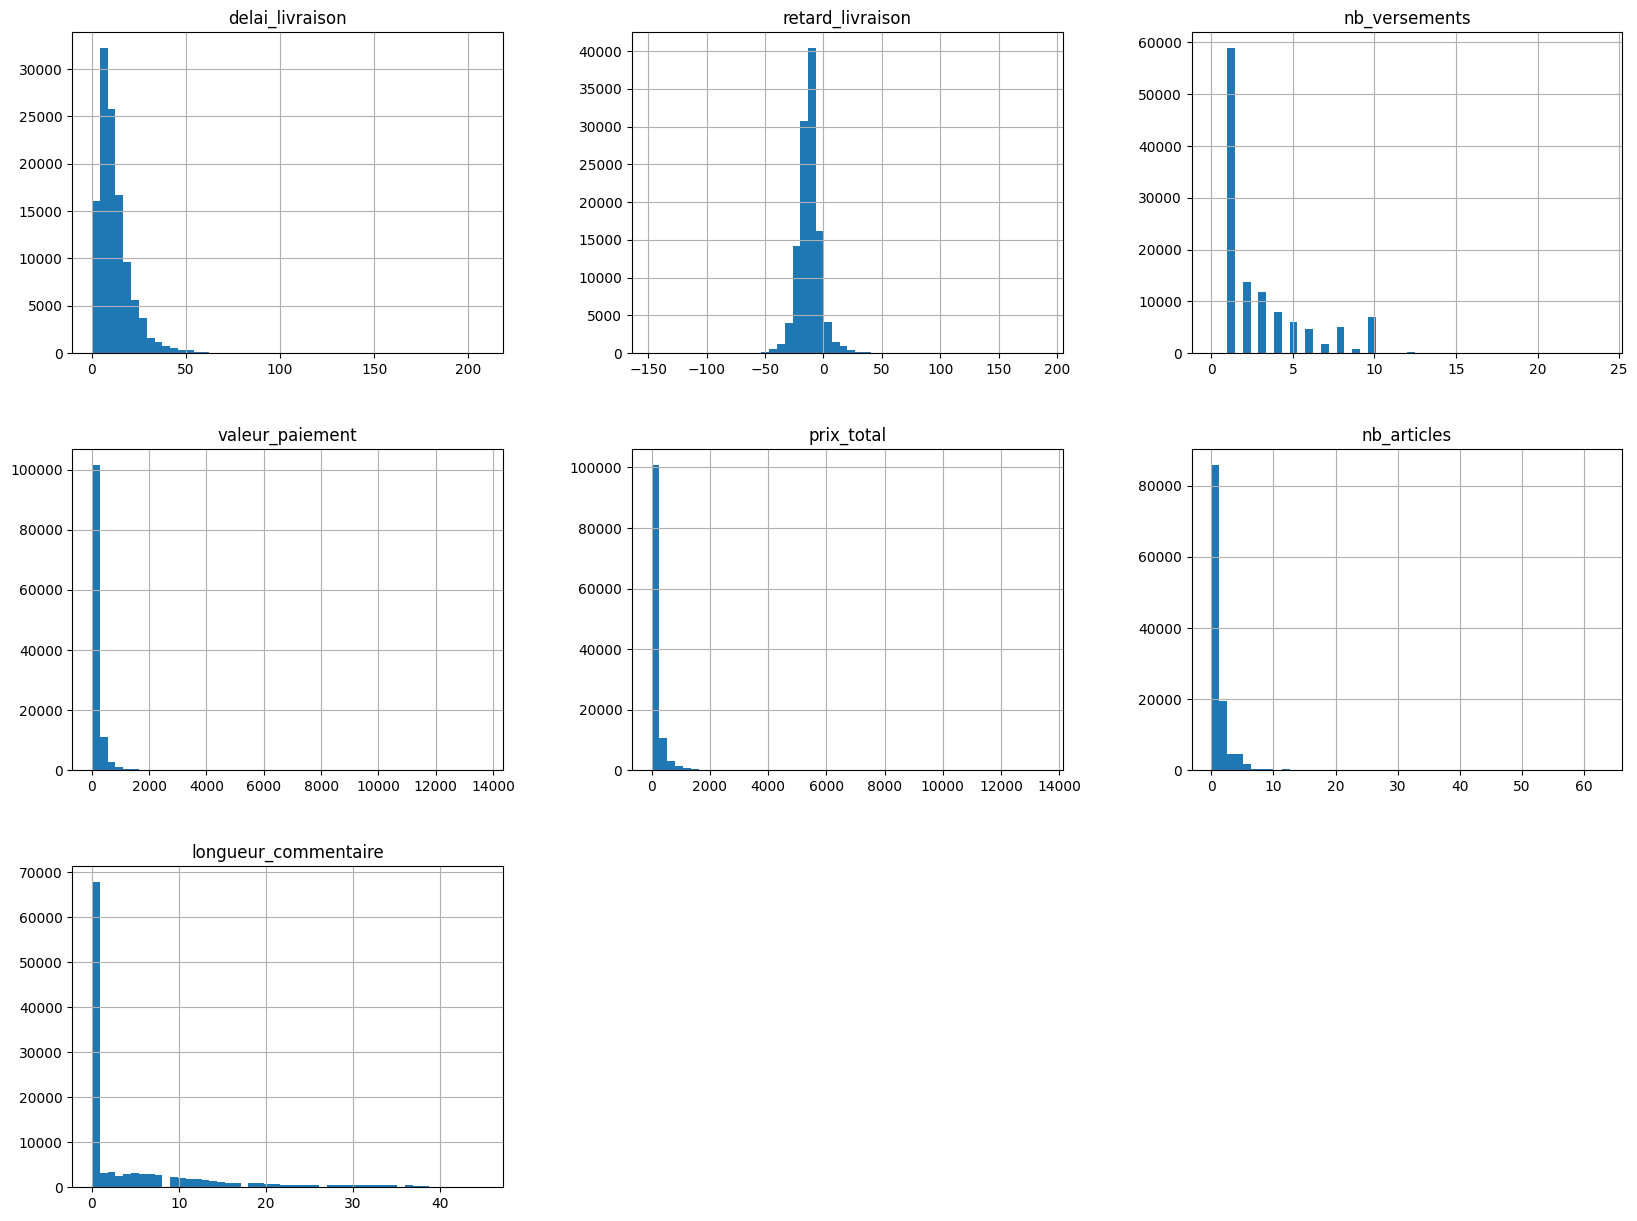

In [13]:
# Observer les diagrammes de distribution des donnees

import matplotlib.pyplot as plt

df[['order_id', 'customer_id', 'product_id', 'product_category_name',
       'delai_livraison', 'retard_livraison', 'nb_versements',
       'valeur_paiement', 'prix_total', 'nb_articles', 'longueur_commentaire']].hist(bins=50, figsize=(20,15))
#plt.title("Distribution des buts marqués à domicile")

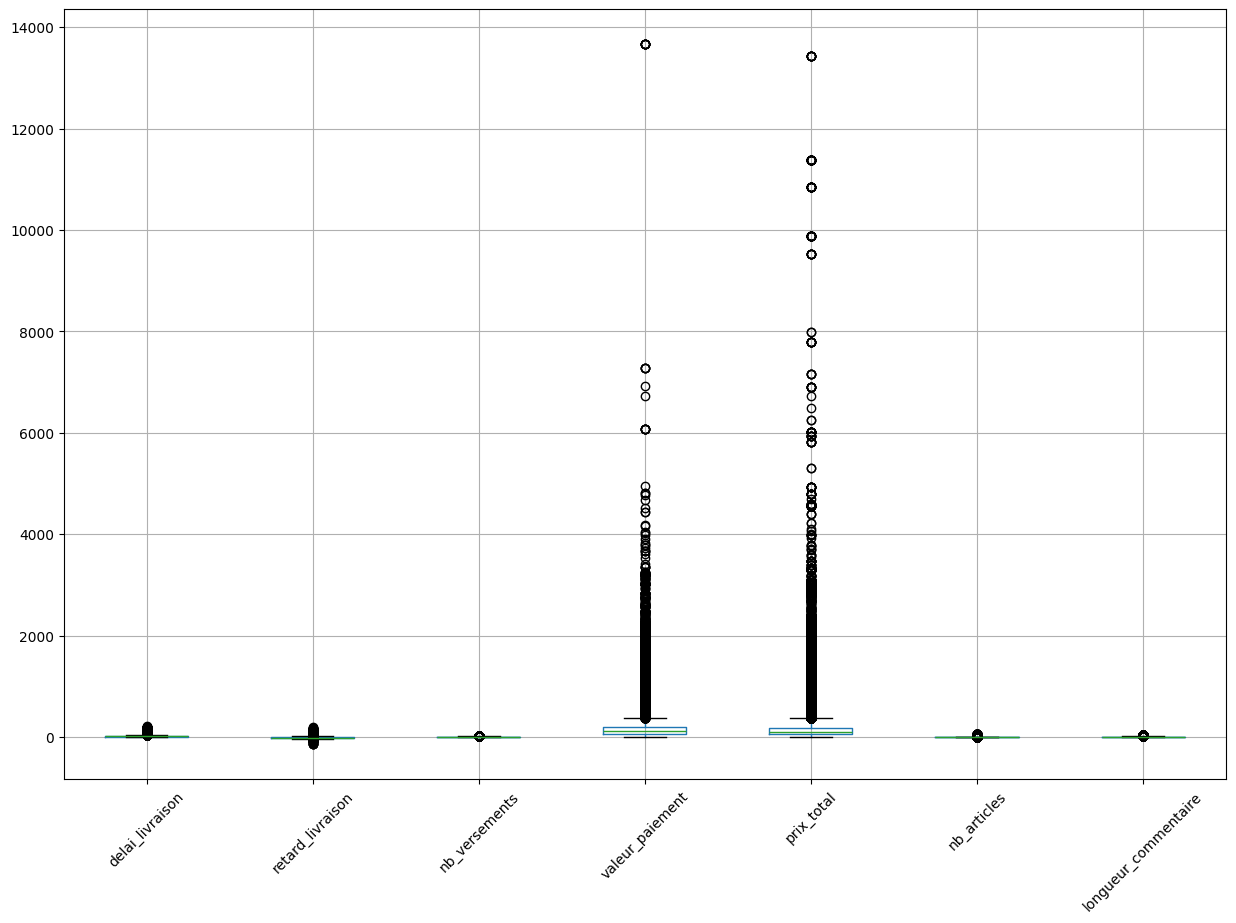

In [14]:
# Apercu des valeurs aberrantes
plt.figure(figsize=(15, 10))  # Taille de la figure 
df.boxplot([
       'delai_livraison', 'retard_livraison', 'nb_versements',
       'valeur_paiement', 'prix_total', 'nb_articles', 'longueur_commentaire'])

plt.xticks(rotation=45)  # Rotation des labels des axes pour qu'ils ne se chevauchent pas

plt.show()


In [15]:
# Afficher les donnees statitiques
df.describe()

,delai_livraison,retard_livraison,nb_versements,valeur_paiement,prix_total,nb_articles,longueur_commentaire,satisfaction
count,114861.000000,114861.000000,118143.000000,118143.000000,118146.000000,118146.000000,118146.000000,118146.000000
mean,11.980472,-12.083318,2.938050,172.204038,182.663374,1.656053,5.132421,0.750444
std,9.373654,10.097310,2.775373,266.016169,425.564739,2.389921,8.710459,0.432758
min,0.000000,-147.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.000000,-17.000000,1.000000,60.730000,49.900000,1.000000,0.000000,1.000000
50%,10.000000,-13.000000,2.000000,108.000000,99.000000,1.000000,0.000000,1.000000
75%,15.000000,-7.000000,4.000000,189.005000,179.700000,2.000000,7.000000,1.000000
max,208.000000,188.000000,24.000000,13664.080000,13440.000000,63.000000,45.000000,1.000000


In [16]:
# Traitement des valeurs aberrantes
colonnes = ['valeur_paiement', 'prix_total']
Q1 = df[colonnes].quantile(0.25)
Q3 = df[colonnes].quantile(0.75)
IQR = Q3 - Q1

minimum = Q1 - 1.5*IQR
maximum = Q3 + 1.5*IQR

for col in colonnes:
    df = df[(df[col] >= minimum[col]) & (df[col] <= maximum[col])]
df.head()

,order_id,customer_id,product_id,product_category_name,delai_livraison,retard_livraison,nb_versements,valeur_paiement,prix_total,nb_articles,longueur_commentaire,satisfaction
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,87285b34884572647811a353c7ac498a,utilidades_domesticas,8.0,-8.0,1.0,18.12,89.97,3,32,1
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,87285b34884572647811a353c7ac498a,utilidades_domesticas,8.0,-8.0,1.0,2.00,89.97,3,32,1
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,87285b34884572647811a353c7ac498a,utilidades_domesticas,8.0,-8.0,1.0,18.59,89.97,3,32,1
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,595fac2a385ac33a80bd5114aec74eb8,perfumaria,13.0,-6.0,1.0,141.46,118.70,1,4,1
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,aa4383b373c6aca5d8797843e5594415,automotivo,9.0,-18.0,3.0,179.12,159.90,1,0,1


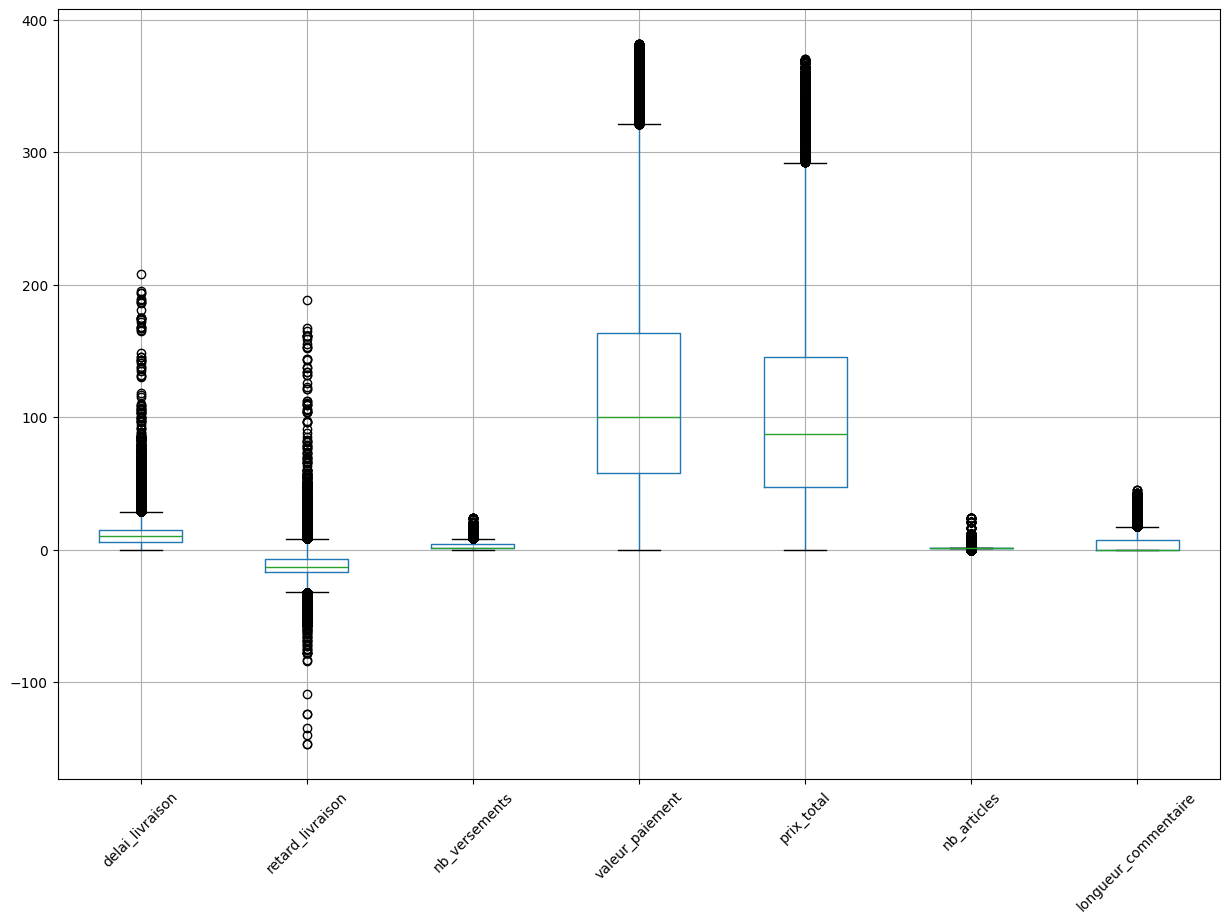

In [17]:
# Reafficher les boxplots des valeurs aberrantes 
plt.figure(figsize=(15, 10))  # Taille de la figure 
df.boxplot([
       'delai_livraison', 'retard_livraison', 'nb_versements',
       'valeur_paiement', 'prix_total', 'nb_articles', 'longueur_commentaire'])

plt.xticks(rotation=45)  # Rotation des labels des axes pour qu'ils ne se chevauchent pas

plt.show()

In [18]:
#Voir la distribution de la target
df['satisfaction'].value_counts()

satisfaction
1    80345
0    25538
Name: count, dtype: int64

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


<Axes: >

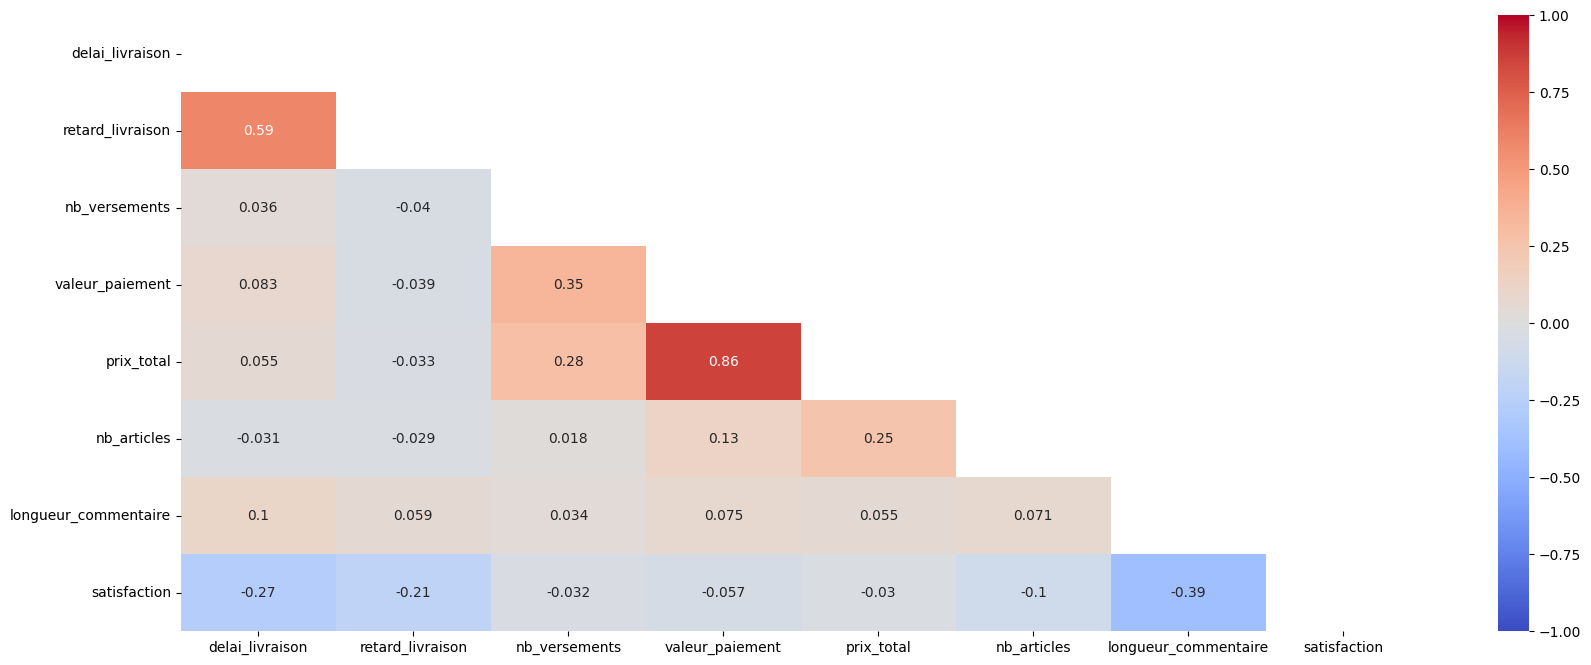

In [19]:
%pip install seaborn

# Observer la correlation avec la cible
import seaborn as sns

matrice = df[[
       'delai_livraison', 'retard_livraison', 'nb_versements',
       'valeur_paiement', 'prix_total', 'nb_articles', 'longueur_commentaire',
       'satisfaction']].corr()
plt.figure(figsize=(20,8))
sns.heatmap(matrice, vmin=-1, vmax=+1, annot=True, cmap='coolwarm', mask=np.triu(matrice))

In [20]:
df.describe()

,delai_livraison,retard_livraison,nb_versements,valeur_paiement,prix_total,nb_articles,longueur_commentaire,satisfaction
count,103045.000000,103045.000000,105883.000000,105883.000000,105883.000000,105883.000000,105883.000000,105883.000000
mean,11.822456,-12.016042,2.741790,120.264748,104.878168,1.387635,4.959861,0.758809
std,9.236115,9.980229,2.546102,80.654375,75.932562,1.034400,8.519568,0.427808
min,0.000000,-147.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.000000,-17.000000,1.000000,58.170000,46.995000,1.000000,0.000000,1.000000
50%,10.000000,-13.000000,1.000000,100.000000,87.000000,1.000000,0.000000,1.000000
75%,15.000000,-7.000000,4.000000,163.260000,145.000000,1.000000,7.000000,1.000000
max,208.000000,188.000000,24.000000,381.320000,369.900000,24.000000,45.000000,1.000000


In [21]:
# Afficher les types de nos caracteristiques
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 105883 entries, 0 to 118145
Data columns (total 12 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               105883 non-null  object 
 1   customer_id            105883 non-null  object 
 2   product_id             105151 non-null  object 
 3   product_category_name  103583 non-null  object 
 4   delai_livraison        103045 non-null  float64
 5   retard_livraison       103045 non-null  float64
 6   nb_versements          105883 non-null  float64
 7   valeur_paiement        105883 non-null  float64
 8   prix_total             105883 non-null  float64
 9   nb_articles            105883 non-null  int64  
 10  longueur_commentaire   105883 non-null  int64  
 11  satisfaction           105883 non-null  int64  
dtypes: float64(5), int64(3), object(4)
memory usage: 10.5+ MB


In [22]:
# Observer les valeurs unique
df.nunique()

order_id                 91570
customer_id              91570
product_id               29630
product_category_name       73
delai_livraison            137
retard_livraison           188
nb_versements               24
valeur_paiement          23191
prix_total                5837
nb_articles                 15
longueur_commentaire        45
satisfaction                 2
dtype: int64

In [23]:
#Apercu des valeurs manquantes
df.isna().sum()

order_id                    0
customer_id                 0
product_id                732
product_category_name    2300
delai_livraison          2838
retard_livraison         2838
nb_versements               0
valeur_paiement             0
prix_total                  0
nb_articles                 0
longueur_commentaire        0
satisfaction                0
dtype: int64

In [24]:
# La proportion des valeurs manquantes
(df.isnull().sum() / len(df)) * 100

order_id                 0.000000
customer_id              0.000000
product_id               0.691329
product_category_name    2.172209
delai_livraison          2.680317
retard_livraison         2.680317
nb_versements            0.000000
valeur_paiement          0.000000
prix_total               0.000000
nb_articles              0.000000
longueur_commentaire     0.000000
satisfaction             0.000000
dtype: float64

Text(0.5, 1.0, 'Distribution de la valeur cible')

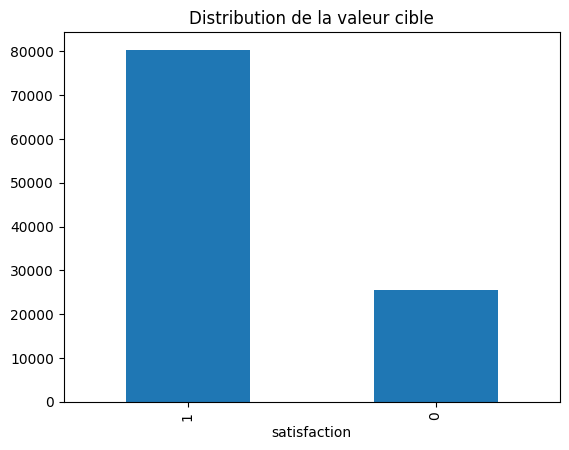

In [25]:
# Apercu de la distribuition du target en diagramme
df['satisfaction'].value_counts().plot(kind='bar')
plt.title('Distribution de la valeur cible')

# 3. Pre-traitement

In [26]:
# Traitement des valeurs manquantes
df['product_id'] = df['product_id'].fillna('unknown')
df['product_category_name'] = df['product_category_name'].fillna('Non specifie')
df['delai_livraison'] = df['delai_livraison'].fillna(df['delai_livraison'].median())
df['retard_livraison'] = df['retard_livraison'].fillna(df['retard_livraison'].median())

In [27]:
# Revisualiser les valeurs manquantes
df.isnull().sum()

order_id                 0
customer_id              0
product_id               0
product_category_name    0
delai_livraison          0
retard_livraison         0
nb_versements            0
valeur_paiement          0
prix_total               0
nb_articles              0
longueur_commentaire     0
satisfaction             0
dtype: int64

In [28]:
# Vérifier le nombre de doublons avant suppression
print(f"Nombre de lignes avant suppression : {len(df)}")
print(f"Nombre de doublons complets : {df.duplicated().sum()}")

# Supprimer les lignes complètement identiques
df = df.drop_duplicates()

print(f"Nombre de lignes après suppression : {len(df)}")


Nombre de lignes avant suppression : 105883
Nombre de doublons complets : 8406
Nombre de lignes après suppression : 97477


In [29]:
df.nunique()

order_id                 91570
customer_id              91570
product_id               29631
product_category_name       74
delai_livraison            137
retard_livraison           188
nb_versements               24
valeur_paiement          23191
prix_total                5837
nb_articles                 15
longueur_commentaire        45
satisfaction                 2
dtype: int64

In [30]:
# Encodage par frequence

# Calcul de la fréquence d'apparition de chaque catégorie
freq_encoding = df['product_category_name'].value_counts(normalize=True)

# Remplacement par la fréquence
df['product_category_encoded'] = df['product_category_name'].map(freq_encoding)

In [31]:
# Suppression des colonnes a supposer unitile
df = df.drop(columns=['order_id', 'customer_id', 'product_id', 'product_category_name'])
df

,delai_livraison,retard_livraison,nb_versements,valeur_paiement,prix_total,nb_articles,longueur_commentaire,satisfaction,product_category_encoded
0,8.0,-8.0,1.0,18.12,89.97,3,32,1,0.060507
1,8.0,-8.0,1.0,2.00,89.97,3,32,1,0.060507
2,8.0,-8.0,1.0,18.59,89.97,3,32,1,0.060507
3,13.0,-6.0,1.0,141.46,118.70,1,4,1,0.032510
4,9.0,-18.0,3.0,179.12,159.90,1,0,1,0.037476
...,...,...,...,...,...,...,...,...,...
118139,11.0,-16.0,3.0,155.99,139.90,1,0,1,0.067657
118140,8.0,-11.0,3.0,85.08,72.00,1,0,1,0.085948
118141,22.0,-2.0,3.0,195.00,174.90,1,10,1,0.028191
118142,24.0,-6.0,5.0,271.01,205.99,1,5,1,0.001344


# 4. Modelisation

In [32]:
# Normalisation des donnees
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X= df.drop(columns=['satisfaction'])
y = df['satisfaction']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [33]:
#Importation des modeles
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.decomposition import PCA
#Importation des mesures de performances
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [34]:
models = {
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'RFC': RandomForestClassifier(random_state=42)
}

cv_results = {}
for name, model in models.items():
    pipe = Pipeline(steps=[
        ("model", model)])
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring="f1")
    cv_results[name] = scores
    print(f"{name} — CV F1: {scores.mean():.3f} ± {scores.std():.3f}")
cv_results

KNN — CV F1: 0.881 ± 0.001
Logistic Regression — CV F1: 0.887 ± 0.001
Decision Tree — CV F1: 0.839 ± 0.004
RFC — CV F1: 0.902 ± 0.001


{'KNN': array([0.87958779, 0.88197824, 0.88156076, 0.87852469, 0.88093354]),
 'Logistic Regression': array([0.88768397, 0.88824484, 0.88708993, 0.8863118 , 0.88766911]),
 'Decision Tree': array([0.84060176, 0.83862278, 0.84348009, 0.83302985, 0.84140079]),
 'RFC': array([0.90199197, 0.90136162, 0.90341765, 0.8992666 , 0.90283722])}

# 5. Optimisation

In [35]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
import numpy as np

rf = RandomForestClassifier(random_state=42)

param_dist_rf = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rs_rf = RandomizedSearchCV(
    rf,
    param_distributions=param_dist_rf,
    n_iter=20,               # nombre d'itérations aléatoires
    scoring='f1',
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=1
)
rs_rf.fit(X_train, y_train)
best_rf = rs_rf.best_estimator_
print("RandomForest best params:", rs_rf.best_params_)
print("RandomForest CV best score (f1):", rs_rf.best_score_)

y_pred_rf = best_rf.predict(X_test)
print("Test F1 (RF):", metrics.f1_score(y_test, y_pred_rf))
print("Accuracy (RF):", metrics.accuracy_score(y_test, y_pred_rf))
print("Confusion matrix (RF):\n", metrics.confusion_matrix(y_test, y_pred_rf))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
RandomForest best params: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}
RandomForest CV best score (f1): 0.9028174814028279
Test F1 (RF): 0.9071381047428951
Accuracy (RF): 0.849661469019286
Confusion matrix (RF):
 [[ 2249  2292]
 [  639 14316]]


In [36]:
import joblib
# Sauvegarder le modèle optimisé
joblib.dump(best_rf, 'best_random_forest_model.pkl')

['best_random_forest_model.pkl']

In [37]:
# Recharger le modèle sauvegardé
import joblib
best_rf = joblib.load('best_random_forest_model.pkl')
best_rf

RandomForestClassifier(min_samples_split=5, random_state=42)

In [38]:
# Démarrer une exécution avec MLflow 
from sklearn import metrics
with mlflow.start_run(run_name='RFC Model - Satisfaction Client'): 
    # Enregistrer les hyperparamètres du modèle 
    mlflow.log_params(best_rf.get_params())

    # Enregistrer le dataset utilisé
    mlflow.log_artifact("olist_dataset_prepared.csv", artifact_path="data")

    # Enregistrer les métriques de performance 
    mlflow.log_metrics({
        "f1_score" : metrics.f1_score(y_test, y_pred_rf),
        "Recall" : metrics.recall_score(y_test, y_pred_rf),
        "ROC AUC" : metrics.roc_auc_score(y_test, y_pred_rf)
    })

    # Sauvegarder le modèle en tant qu'artifact (évite l'appel à l'endpoint "log_model" qui peut poser problème)
    # Si le fichier n'existe pas encore, le créer (joblib a été importé et utilisé précédemment)
    if not os.path.exists('best_random_forest_model.pkl'):
        joblib.dump(best_rf, 'best_random_forest_model.pkl')
    mlflow.log_artifact('best_random_forest_model.pkl', artifact_path='models')

🏃 View run RFC Model - Satisfaction Client at: https://dagshub.com/ibou224/Satisfaction-Client-ProjetIA2025.mlflow/#/experiments/0/runs/7c9e12f43e8548308b757e45e29566a6
🧪 View experiment at: https://dagshub.com/ibou224/Satisfaction-Client-ProjetIA2025.mlflow/#/experiments/0


In [39]:
# Recharger le modèle sauvegardé
best_rf = joblib.load('best_random_forest_model.pkl')
best_rf

RandomForestClassifier(min_samples_split=5, random_state=42)

In [40]:
print("F1 (RF):", metrics.f1_score(y_test, y_pred_rf))
print("Precision (RF):", metrics.precision_score(y_test, y_pred_rf))
print("Recall (RF):", metrics.recall_score(y_test, y_pred_rf))
print("ROC AUC (RF):", metrics.roc_auc_score(y_test, y_pred_rf))

F1 (RF): 0.9071381047428951
Precision (RF): 0.8619942196531792
Recall (RF): 0.957271815446339
ROC AUC (RF): 0.7262685877495954


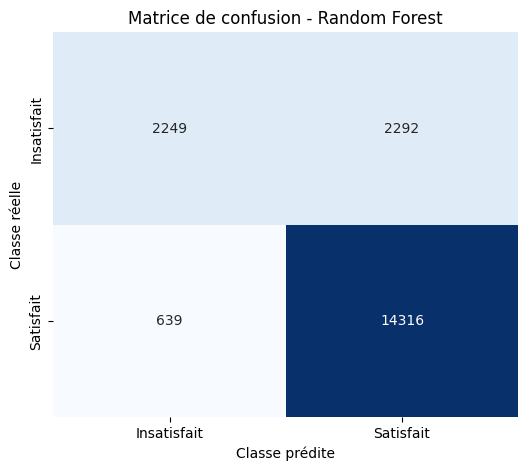

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Génération de la matrice de confusion
cm = confusion_matrix(y_test, y_pred_rf)

# Affichage graphique avec seaborn
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Insatisfait', 'Satisfait'],
            yticklabels=['Insatisfait', 'Satisfait'])

plt.title("Matrice de confusion - Random Forest")
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.show()
